# ResNet 18 Experiments

In [1]:
try:
    import medmnist
except ImportError:
    ! pip install medmnist
    import medmnist

from helpers import create_resnet, train_model, plot_train_hist

from medmnist import DermaMNIST, INFO
import torch
from torchvision.transforms import v2 as transforms, Compose
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

print(medmnist.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.1 MB/s eta 0:00:00
3.0.2


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [3]:
# settings
DOWNLOAD = True
SIZE = 64
BATCH_SIZE = 64
NUM_WORKERS = 2

SEED = 912742984

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

# print dataset info
info = INFO['dermamnist']

### ResNet 18

A baseline model: no data augmentation, train for 5 epochs

In [4]:
# transforms
basic_transform = Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = basic_transform)
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 100M/100M [00:06<00:00, 16.7MB/s] 


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]
100%|██████████| 16/16 [00:00<00:00, 39.74it/s]


Epoch 0 |Train loss: 1.0805, acc: 0.665 |Val loss: 0.8829, acc: 0.727


100%|██████████| 16/16 [00:00<00:00, 25.30it/s]


Epoch 1 |Train loss: 0.8328, acc: 0.716 |Val loss: 0.8281, acc: 0.736


...

100%|██████████| 16/16 [00:00<00:00, 40.51it/s]


Epoch 3 |Train loss: 0.7460, acc: 0.735 |Val loss: 0.8129, acc: 0.738


100%|██████████| 16/16 [00:00<00:00, 37.95it/s]


Epoch 4 |Train loss: 0.7268, acc: 0.745 |Val loss: 0.7994, acc: 0.743


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

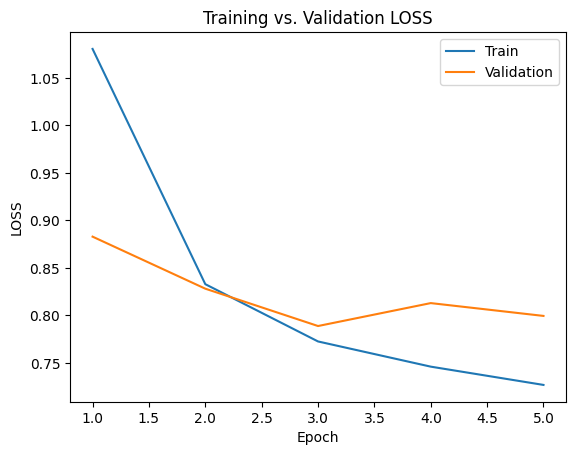

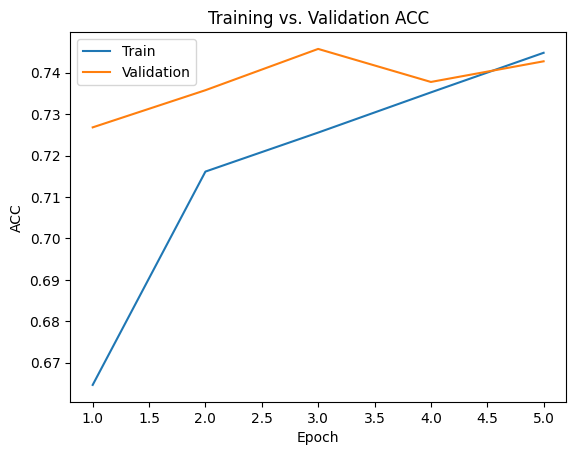

In [5]:
# create a fresh model (for reproducibility)
model = create_resnet(size=18)

# freeze all layers except classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

train_history = train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

plot_train_hist(train_history, type='loss')
plot_train_hist(train_history, type='acc')

This model sucks!!! Only 75% accuracy. (But the accuracy is already MUCH better than Pibu.ai).

I will try training longer to see if this ever overfits and how much it can improve.

100%|██████████| 16/16 [00:00<00:00, 25.61it/s]


Epoch 0 |Train loss: 1.0713, acc: 0.666 |Val loss: 0.8824, acc: 0.720


100%|██████████| 16/16 [00:00<00:00, 40.14it/s]


Epoch 1 |Train loss: 0.8328, acc: 0.714 |Val loss: 0.8190, acc: 0.733


100%|██████████| 16/16 [00:00<00:00, 37.62it/s]


...

100%|██████████| 16/16 [00:00<00:00, 36.14it/s]


Epoch 28 |Train loss: 0.6336, acc: 0.765 |Val loss: 0.8103, acc: 0.755


100%|██████████| 16/16 [00:00<00:00, 23.97it/s]

Epoch 29 |Train loss: 0.6372, acc: 0.767 |Val loss: 0.8182, acc: 0.748


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

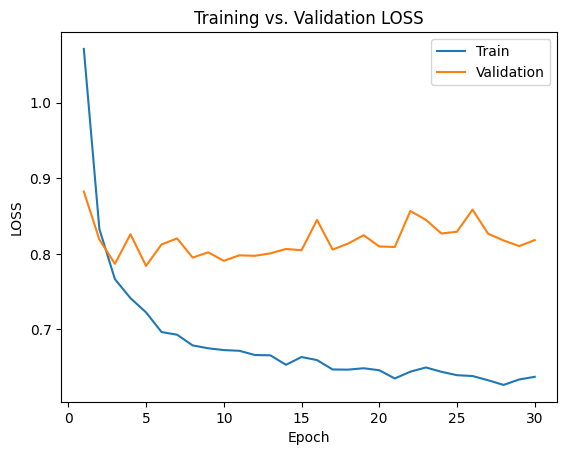

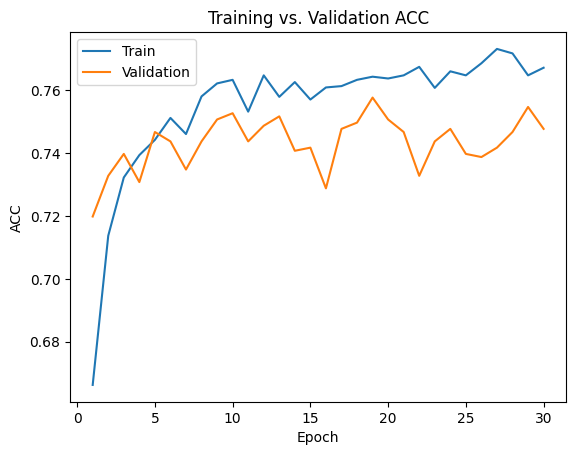

In [6]:
# longer epochs trained

NUM_EPOCHS = 30

model = create_resnet(size=18)

# freeze all layers except classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

train_history = train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

plot_train_hist(train_history, type='loss')
plot_train_hist(train_history, type='acc')

It looks like the loss and accuracy kind of plateau, with maybe slight overfitting at 50 epochs.

- train to 15 epochs (to still see overfitting if present, but not show too much)
- Apply data augmentation to see if we can improve model

**AI Usage:** I asked ChatGPT to suggest some data augmentations I can do for dermatoscope images. I also asked it to generate PyTorch code for the augmentations it suggested (in the variable `data_augmentation_1`). This code is used below. I also uploaded the sample images back to ChatGPT and asked it to refine the data augmentations in follow-up prompts.

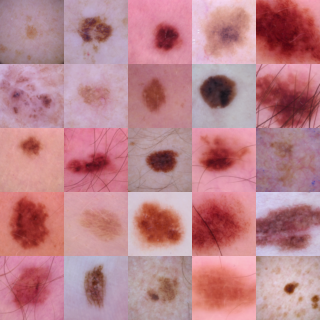

In [7]:
NUM_EPOCHS = 30

# data augmentations to test
data_augmentation_1 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    transforms.RandomResizedCrop(
        size=64,
        scale=(0.95, 1.0),          # only small crops
        ratio=(0.95, 1.05)
    ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    transforms.ColorJitter(
        brightness=0.05,            # ±5%
        contrast=0.05,              # ±5%
        saturation=0.05,            # ±5%
        hue=0.01                    # very small hue shift
    ),

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

100%|██████████| 16/16 [00:00<00:00, 39.35it/s]


Epoch 0 |Train loss: 1.1071, acc: 0.658 |Val loss: 1.0149, acc: 0.701


100%|██████████| 16/16 [00:00<00:00, 35.48it/s]


Epoch 1 |Train loss: 0.9096, acc: 0.695 |Val loss: 0.9397, acc: 0.696


100%|██████████| 16/16 [00:00<00:00, 24.06it/s]


...

100%|██████████| 16/16 [00:01<00:00, 14.98it/s]


Epoch 28 |Train loss: 0.7886, acc: 0.716 |Val loss: 0.8524, acc: 0.709


100%|██████████| 16/16 [00:00<00:00, 19.18it/s]

Epoch 29 |Train loss: 0.8060, acc: 0.715 |Val loss: 0.8687, acc: 0.716


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

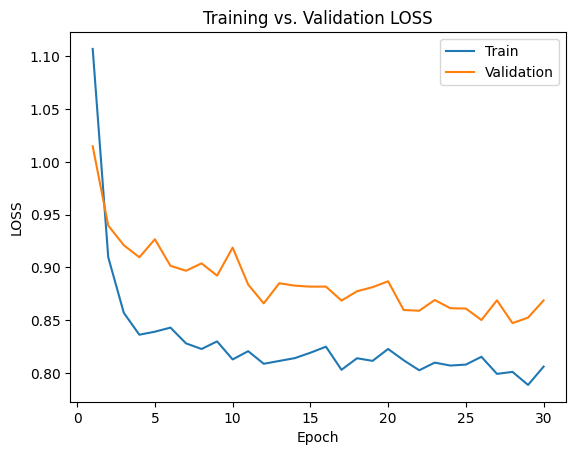

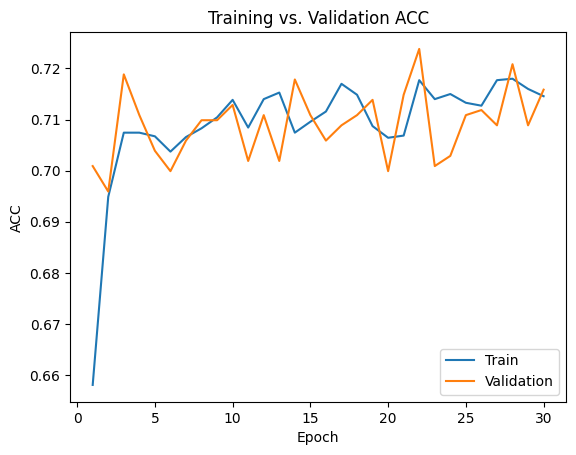

In [8]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = create_resnet(size=18)

# freeze all layers except classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

train_history = train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

plot_train_hist(train_history, type='loss')
plot_train_hist(train_history, type='acc')